# TSE Prompt-Format Ablation — QwenVL-8B-Instruct · 4 Conditions

**Experiment:** `tse_prompt_format_ablation_qwenvl`  
**Setup:** random picking · k=1 · 3 seeds (0, 3, 6) · Qwen3-VL-8B-Instruct  

| # | `--prompt_format` | Has examples? | Has question? | Question position |
|---|---|---|---|---|
| 1 | `no_support` | No (zero-shot) | Yes | Before query |
| 2 | `desc_first` | Yes (k=1) | Yes | Before examples |
| 3 | `no_desc` | Yes (k=1) | No | — |
| 4 | `desc_last` | Yes (k=1) | Yes | After examples, before query |

**Primary metric:** pooled accuracy = total correct / total questions  
(TSE test sets are class-balanced, so balanced_accuracy == regular accuracy per run.  
Pooled accuracy = Σ(balanced_accuracy × total_test_size) / Σ(total_test_size).)

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wilcoxon
from tqdm.auto import tqdm
import json

if wandb.api.api_key is None:
    for folder in ["", "wandb_logger", "logger"]:
        token_path = Path(folder) / "token.txt"
        if token_path.exists():
            wandb.login(key=token_path.read_text().strip())
            break

ENTITY  = "aviramom-"
PROJECT = "ts-icl"
EXP_ID  = "tse_prompt_format_ablation_qwenvl"

MODEL      = "Qwen/Qwen3-VL-8B-Instruct"
N_SEEDS    = 3  # seeds 0, 3, 6
CONDITIONS = ["no_support", "desc_first", "no_desc", "desc_last"]

TSE_META_PATH = Path("../qa_dataset_augmented.json")
if not TSE_META_PATH.exists():
    TSE_META_PATH = Path("qa_dataset_augmented.json")

api = wandb.Api(timeout=60)
print(f"Connected to {ENTITY}/{PROJECT}")
print(f"  Exp ID : {EXP_ID}")

/home/aviramom/.conda/envs/multits/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Connected to aviramom-/ts-icl
  Exp ID : tse_prompt_format_ablation_qwenvl


## 1 · Load Data from W&B

Set `FORCE_REFRESH = True` to re-pull from W&B when new runs finish.

In [2]:
CONFIG_KEYS = ["task_id", "method", "num_samples", "exp_id",
               "num_shots", "random_seed", "picking_strategy", "prompt_format"]
METRIC_KEYS = ["balanced_accuracy", "f1_macro", "f1_weighted",
               "num_of_classes", "total_test_size", "flawed_count", "flawed_percentage"]

CACHE_PATH    = Path("cache_tse_prompt_format_ablation.parquet")
FORCE_REFRESH = True

def get_val(cfg, summary, key):
    return summary.get(key, cfg.get(key))

def fetch_exp(exp_id, cache_path):
    if cache_path.exists() and not FORCE_REFRESH:
        df = pd.read_parquet(cache_path)
        print(f"Loaded {len(df)} rows from cache ({cache_path})")
        return df
    all_runs = list(api.runs(path=f"{ENTITY}/{PROJECT}", per_page=1000))
    rows = []
    for run in tqdm(all_runs, desc=f"Processing {exp_id}"):
        summary = {k: v for k, v in (run.summary or {}).items() if not k.startswith("_")}
        cfg     = run.config or {}
        if get_val(cfg, summary, "exp_id") != exp_id:
            continue
        row = {"run_id": run.id, "run_name": run.name, "state": run.state}
        for k in CONFIG_KEYS:
            row[k] = get_val(cfg, summary, k)
        for k in METRIC_KEYS:
            row[k] = get_val(cfg, summary, k)
        rows.append(row)
    df = pd.DataFrame(rows)
    for col in METRIC_KEYS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df.to_parquet(cache_path)
    print(f"Cached {len(df)} rows → {cache_path}")
    return df

df_raw = fetch_exp(EXP_ID, CACHE_PATH)

df_raw["tid"] = pd.to_numeric(
    df_raw["task_id"].str.replace("icl_tse_", "", regex=False),
    errors="coerce"
).astype("Int64")

print(f"\n{'─'*55}")
print(f"Total runs loaded : {len(df_raw)}")
print(f"Finished          : {(df_raw['state'] == 'finished').sum()}")
print(f"\nCondition counts:")
for cond in CONDITIONS:
    n  = (df_raw["prompt_format"] == cond).sum()
    nf = ((df_raw["prompt_format"] == cond) & (df_raw["state"] == "finished")).sum()
    print(f"  {cond:15s}: {n:4d} total, {nf:4d} finished")

Processing tse_prompt_format_ablation_qwenvl:   0%|          | 0/3816 [00:00<?, ?it/s]

Cached 1176 rows → cache_tse_prompt_format_ablation.parquet

───────────────────────────────────────────────────────
Total runs loaded : 1176
Finished          : 1128

Condition counts:
  no_support     :  294 total,  282 finished
  desc_first     :  294 total,  282 finished
  no_desc        :  294 total,  282 finished
  desc_last      :  294 total,  282 finished


In [3]:
finished = df_raw[df_raw["state"] == "finished"].copy()
tids     = sorted(finished["tid"].dropna().unique().tolist())

print(f"Templates present in results : {len(tids)}")
print(f"Total finished runs          : {len(finished)}")
print()

count_check = finished.pivot_table(
    index="tid", columns="prompt_format",
    values="balanced_accuracy", aggfunc="count"
).reindex(columns=CONDITIONS).fillna(0).astype(int)
incomplete = count_check[(count_check < N_SEEDS).any(axis=1)]
print(f"Templates with < {N_SEEDS} seeds in any condition: {len(incomplete)}")
if len(incomplete) > 0:
    print("Incomplete templates:")
    display(incomplete)

Templates present in results : 94
Total finished runs          : 1128

Templates with < 3 seeds in any condition: 0


In [4]:
if TSE_META_PATH.exists():
    with open(TSE_META_PATH) as f:
        tse_entries = json.load(f)
    tid_meta = {}
    for e in tse_entries:
        t = e["tid"]
        if t not in tid_meta:
            tid_meta[t] = {
                "difficulty":  e.get("difficulty", "unknown"),
                "category":    e.get("category",   "unknown"),
                "question":    e.get("question",   ""),
            }
    print(f"Loaded metadata for {len(tid_meta)} tids from {TSE_META_PATH}")
else:
    tid_meta = {}
    print("WARNING: qa_dataset_augmented.json not found")

Loaded metadata for 98 tids from ../qa_dataset_augmented.json


## 2 · Pooled Accuracy Table

**Pooled accuracy = total correct / total questions** across all templates and seeds.  
Since TSE test sets are class-balanced, `balanced_accuracy == accuracy` per run,  
so `pooled = Σ(balanced_accuracy × total_test_size) / Σ(total_test_size)`.

In [5]:
COLOR_MAP = {
    "no_support": "#7B1FA2",
    "desc_first":  "#1565C0",
    "no_desc":     "#2E7D32",
    "desc_last":   "#B71C1C",
}

COND_LABELS = {
    "no_support": "no_support  (0-shot + question)",
    "desc_first":  "desc_first  (question → examples → query)",
    "no_desc":     "no_desc     (examples → query)",
    "desc_last":   "desc_last   (examples → question → query)",
}

rows = []
for cond in CONDITIONS:
    cdf = finished[finished["prompt_format"] == cond]
    if cdf.empty:
        continue
    total_correct   = (cdf["balanced_accuracy"] * cdf["total_test_size"]).sum()
    total_questions = cdf["total_test_size"].sum()
    pooled_acc      = total_correct / total_questions

    per_tid = cdf.groupby("tid")["balanced_accuracy"].mean()
    macro_acc = per_tid.mean()

    rows.append({
        "prompt_format":     cond,
        "Description":       COND_LABELS[cond],
        "Templates":         cdf["tid"].nunique(),
        "Runs":              len(cdf),
        "Total Questions":   int(total_questions),
        "Pooled Accuracy":   pooled_acc,
        "Macro Bal. Acc":    macro_acc,
    })

summary_df = pd.DataFrame(rows).set_index("prompt_format")

print("POOLED ACCURACY — total correct / total questions")
display(
    summary_df.style
    .format({
        "Templates":       "{:.0f}",
        "Runs":            "{:.0f}",
        "Total Questions": "{:,}",
        "Pooled Accuracy": "{:.4f}",
        "Macro Bal. Acc":  "{:.4f}",
    })
    .background_gradient(cmap="RdYlGn", axis=0,
                         subset=["Pooled Accuracy", "Macro Bal. Acc"], vmin=0, vmax=1)
    .set_caption("Pooled accuracy across all templates · 3 seeds · QwenVL-8B-Instruct")
)

POOLED ACCURACY — total correct / total questions


,Description,Templates,Runs,Total Questions,Pooled Accuracy,Macro Bal. Acc
prompt_format,,,,,,
no_support,no_support (0-shot + question),94,282,"2,079",0.5883,0.6014
desc_first,desc_first (question → examples → query),94,282,"2,079",0.7937,0.7981
no_desc,no_desc (examples → query),94,282,"2,079",0.7869,0.7970
desc_last,desc_last (examples → question → query),94,282,"2,079",0.7480,0.7546


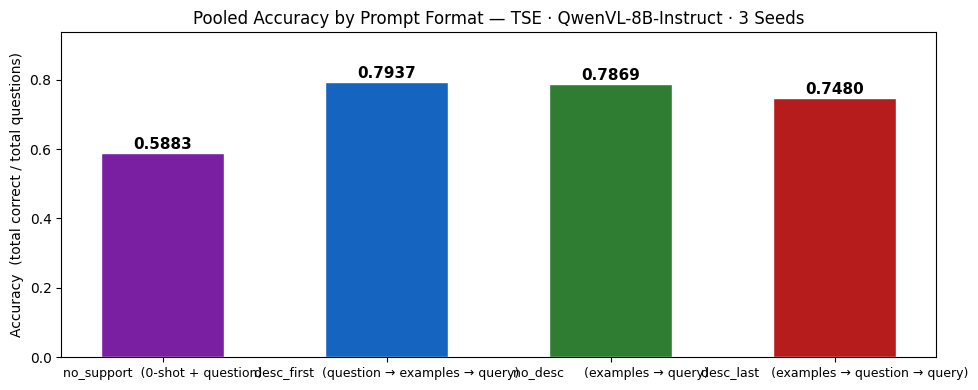

In [6]:
conds_present = [c for c in CONDITIONS if c in summary_df.index]
pooled_vals   = summary_df.loc[conds_present, "Pooled Accuracy"].values
bar_colors    = [COLOR_MAP[c] for c in conds_present]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    [COND_LABELS[c] for c in conds_present],
    pooled_vals, color=bar_colors, width=0.55, edgecolor="white"
)
for bar, val in zip(bars, pooled_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(pooled_vals) * 1.18)
ax.set_ylabel("Accuracy  (total correct / total questions)")
ax.set_title("Pooled Accuracy by Prompt Format — TSE · QwenVL-8B-Instruct · 3 Seeds")
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

## 3 · Per-Template Accuracy

Mean accuracy across 3 seeds per template.  
Δ columns show difference relative to `no_desc` (the baseline ICL condition).

In [7]:
mean_p = finished.pivot_table(
    index="tid", columns="prompt_format",
    values="balanced_accuracy", aggfunc="mean"
).reindex(columns=CONDITIONS)
mean_p.columns.name = ""

baseline = "no_desc"
for cond in CONDITIONS:
    if cond != baseline and cond in mean_p.columns:
        mean_p[f"Δ vs {baseline} ({cond})"] = mean_p[cond] - mean_p[baseline]

delta_cols = [c for c in mean_p.columns if c.startswith("Δ")]

mean_p["Difficulty"] = pd.Series({t: tid_meta.get(t, {}).get("difficulty", "?") for t in mean_p.index})
mean_p["Category"]   = pd.Series({t: tid_meta.get(t, {}).get("category",   "?") for t in mean_p.index})
mean_p["Question"]   = pd.Series({t: tid_meta.get(t, {}).get("question",   "")[:55] for t in mean_p.index})

display_cols = CONDITIONS + delta_cols + ["Difficulty", "Category", "Question"]
display_cols = [c for c in display_cols if c in mean_p.columns]

display(
    mean_p[display_cols].style
    .background_gradient(cmap="RdYlGn", axis=None, subset=CONDITIONS, vmin=0, vmax=1)
    .background_gradient(cmap="RdBu", axis=None, subset=delta_cols,
                         vmin=-mean_p[delta_cols].abs().max().max(),
                         vmax=mean_p[delta_cols].abs().max().max())
    .format("{:.3f}", subset=CONDITIONS, na_rep="—")
    .format("{:+.3f}", subset=delta_cols, na_rep="—")
    .set_caption("Mean balanced accuracy per template (3 seeds) + Δ vs no_desc")
)

,no_support,desc_first,no_desc,desc_last,Δ vs no_desc (no_support),Δ vs no_desc (desc_first),Δ vs no_desc (desc_last),Difficulty,Category,Question
tid,,,,,,,,,,
1,0.741,0.778,0.630,0.778,+0.111,+0.148,+0.148,easy,Pattern Recognition,What is the type of the trend of the given time series?
2,0.667,1.000,0.963,0.963,-0.296,+0.037,+0.000,hard,Pattern Recognition,What is the most likely linear trend coefficient of the
3,0.889,0.889,0.833,0.722,+0.056,+0.056,-0.111,easy,Pattern Recognition,Does the given time series exhibit any monotonic increa
4,1.000,1.000,0.889,1.000,+0.111,+0.111,+0.111,easy,Pattern Recognition,What is the direction of the linear trend of the given
5,0.333,0.741,0.778,0.667,-0.444,-0.037,-0.111,hard,Pattern Recognition,Given that following time series exhibit piecewise line
6,0.500,0.611,0.500,0.667,+0.000,+0.111,+0.167,easy,Pattern Recognition,How does the linear trend in the first half of the time
7,0.667,0.611,0.611,0.722,+0.056,+0.000,+0.111,hard,Pattern Recognition,"The given time series has an increasing trend, is it a"
8,0.444,0.778,0.556,0.833,-0.111,+0.222,+0.278,hard,Pattern Recognition,"The given time series has a decreasing trend, is it a l"
9,0.333,0.778,0.778,0.694,-0.444,+0.000,-0.083,hard,Pattern Recognition,The given time series has multiple trends followed by e


## 4 · Wilcoxon Tests vs `no_desc`

Paired signed-rank test per condition vs the `no_desc` baseline.

In [8]:
def sig(p):
    return "*** (p<0.001)" if p < 0.001 else "** (p<0.01)" if p < 0.01 else "* (p<0.05)" if p < 0.05 else "n.s."

wilcox_rows = []
for cond in CONDITIONS:
    if cond == baseline or cond not in mean_p.columns:
        continue
    paired = mean_p[[baseline, cond]].dropna()
    a, b   = paired[baseline].values, paired[cond].values
    delta  = b - a
    try:
        stat, p = wilcoxon(b, a, zero_method="pratt", alternative="two-sided")
    except ValueError:
        stat, p = np.nan, np.nan
    wilcox_rows.append({
        "Condition":          cond,
        "Mean (baseline)": a.mean(),
        "Mean (cond)": b.mean(),
        "Mean Δ": delta.mean(),
        "Templates improved": int((delta > 0).sum()),
        "Templates hurt":     int((delta < 0).sum()),
        "Wilcoxon stat":      stat,
        "p-value":            p,
        "Significance":       sig(p),
    })

wilcox_df = pd.DataFrame(wilcox_rows).set_index("Condition")

display(
    wilcox_df.style
    .format({
        "Mean (baseline)": "{:.4f}",
        "Mean (cond)": "{:.4f}",
        "Mean Δ": "{:+.4f}",
        "Wilcoxon stat": "{:.1f}",
        "p-value": "{:.4f}",
    })
    .background_gradient(cmap="RdBu", subset=["Mean Δ"], axis=0)
    .set_caption("Wilcoxon signed-rank test vs no_desc (two-sided, paired over templates)")
)

print(f"\nBaseline (no_desc) macro balanced accuracy: {mean_p[baseline].mean():.4f}")

,Mean (baseline),Mean (cond),Mean Δ,Templates improved,Templates hurt,Wilcoxon stat,p-value,Significance
Condition,,,,,,,,
no_support,0.7970,0.6014,-0.1956,18,70,554.5,0.0000,*** (p<0.001)
desc_first,0.7970,0.7981,+0.0011,41,36,2023.0,0.6148,n.s.
desc_last,0.7970,0.7546,-0.0424,31,45,1608.0,0.0413,* (p<0.05)



Baseline (no_desc) macro balanced accuracy: 0.7970


## 5 · Δ vs `no_desc` per Template

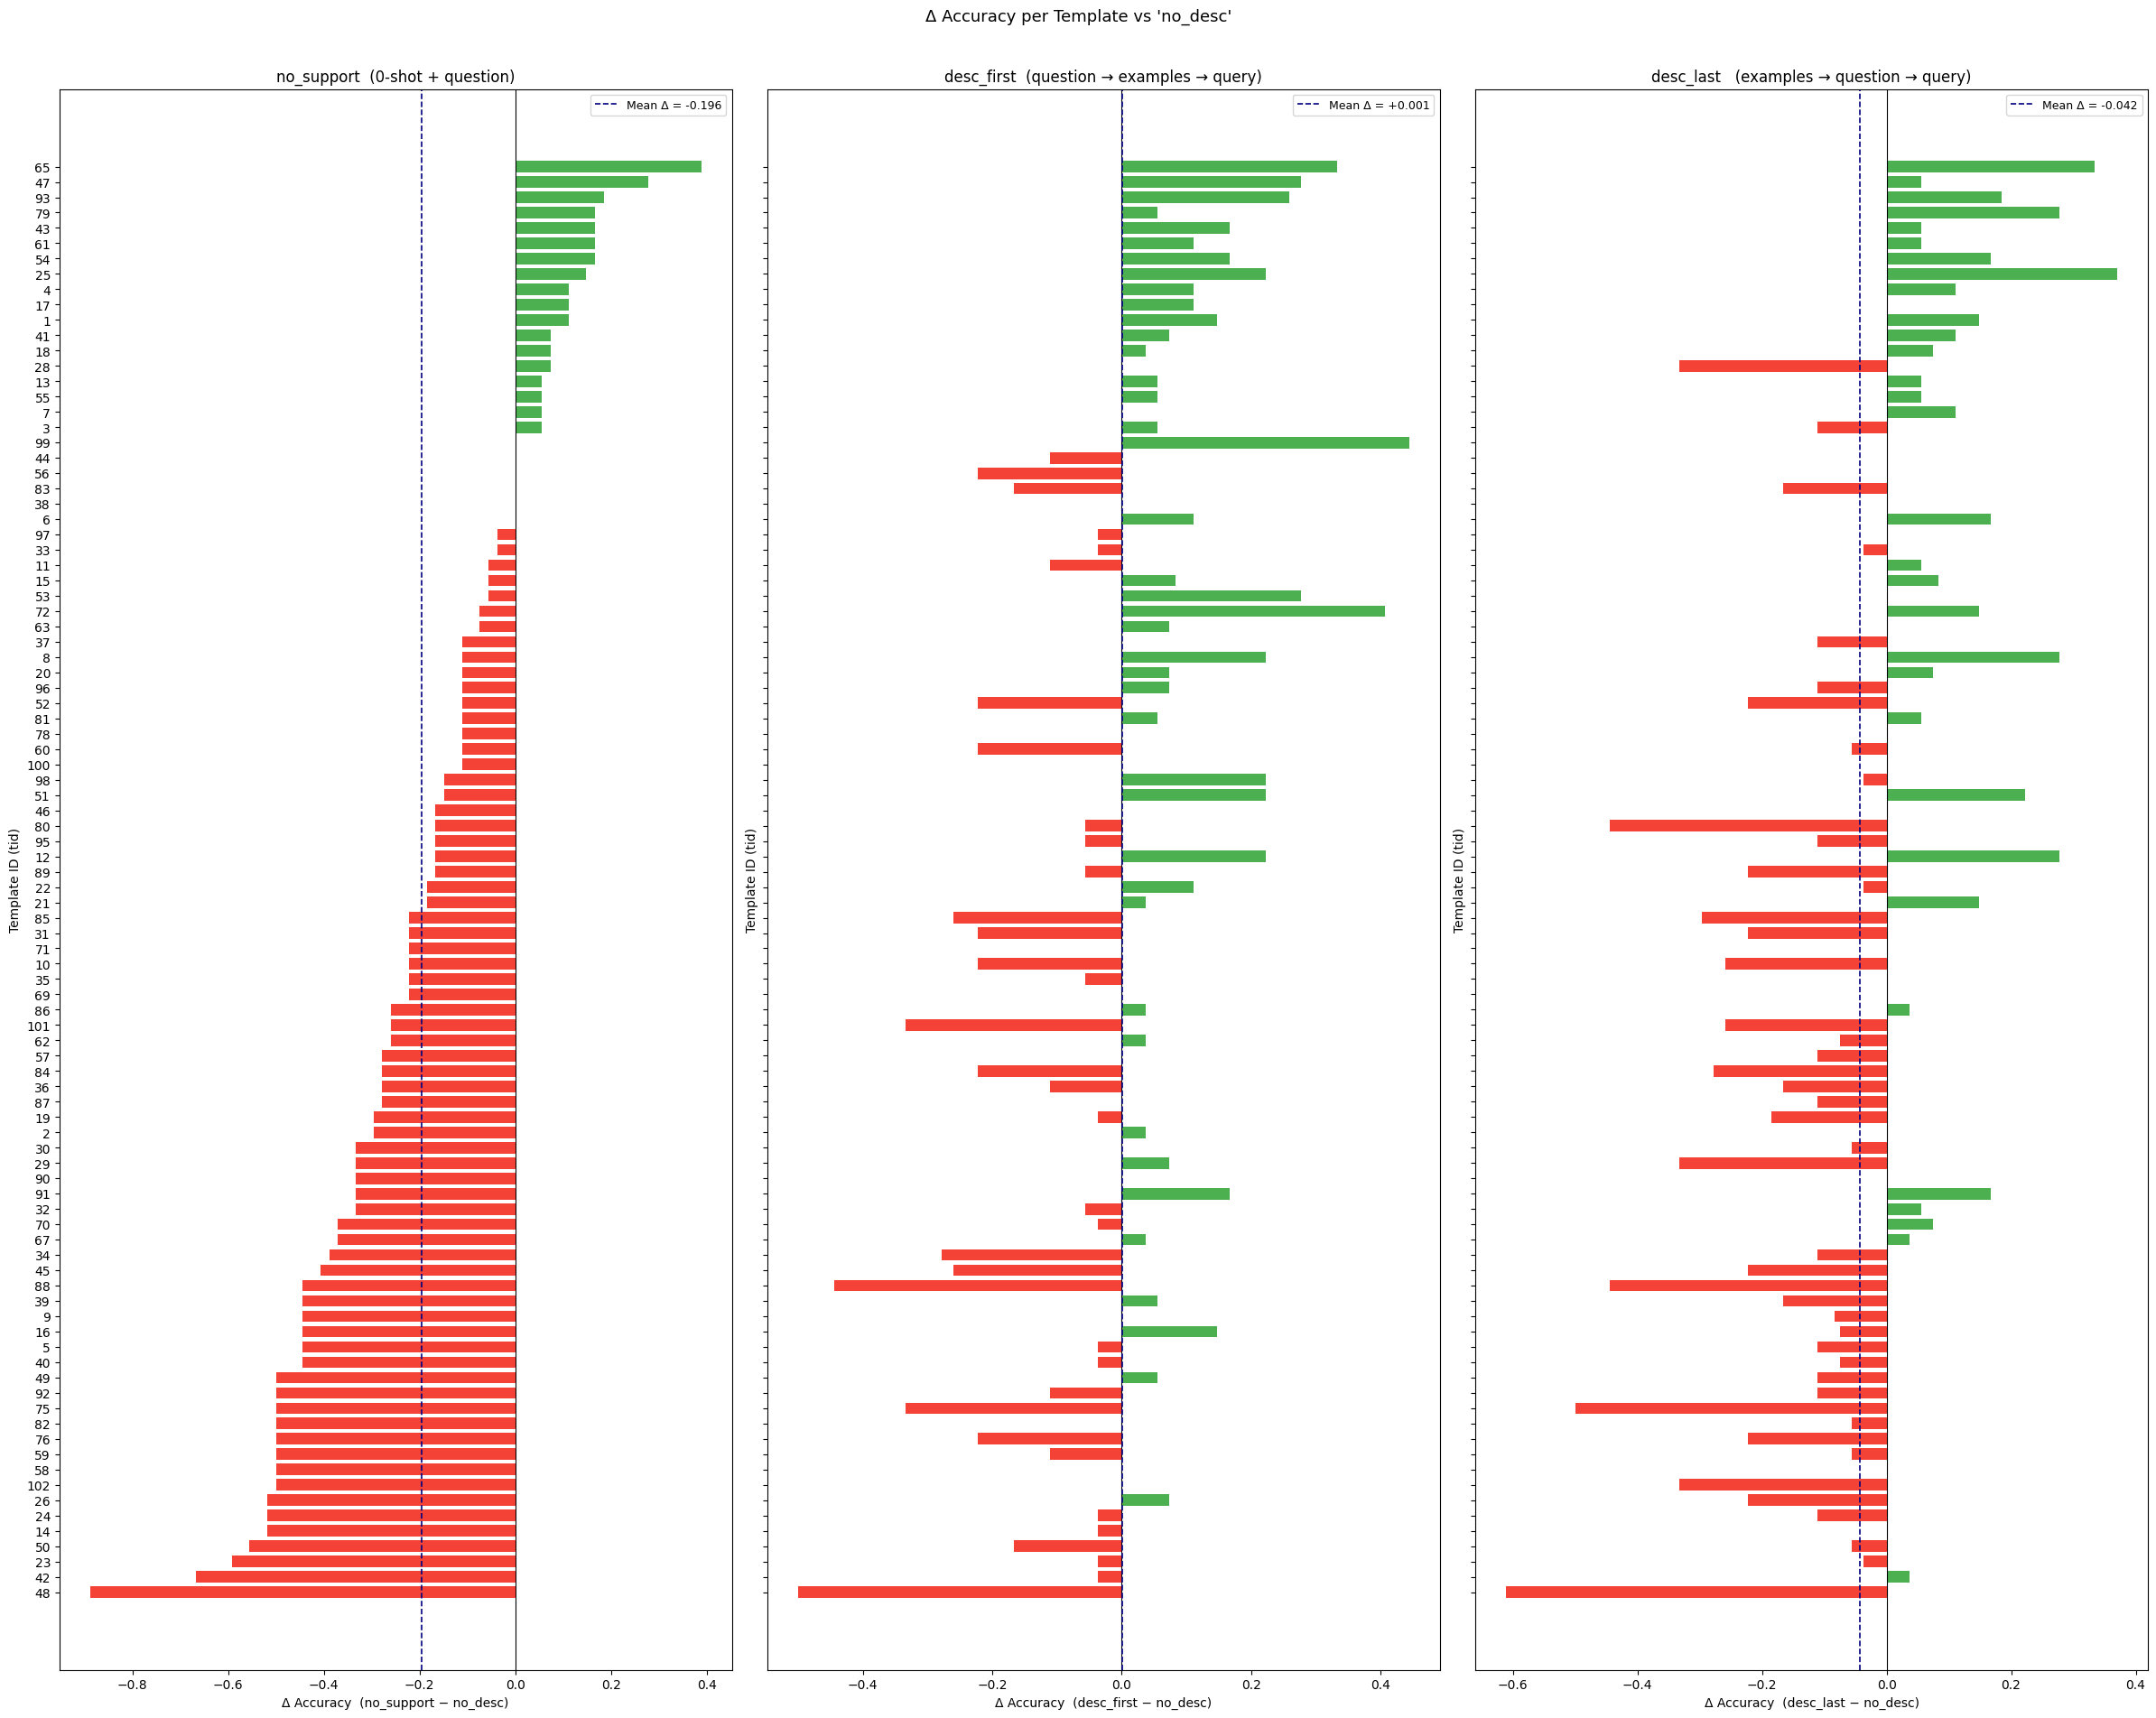

In [9]:
compare_conds = [c for c in CONDITIONS if c != baseline and c in mean_p.columns]

fig, axes = plt.subplots(1, len(compare_conds),
                          figsize=(8 * len(compare_conds), max(5, len(tids) * 0.20)),
                          sharey=True)
if len(compare_conds) == 1:
    axes = [axes]

for ax, cond in zip(axes, compare_conds):
    delta = (mean_p[cond] - mean_p[baseline]).dropna().sort_values(ascending=False)
    colors = ["#4CAF50" if v >= 0 else "#F44336" for v in delta]
    ax.barh(delta.index.astype(str)[::-1], delta.values[::-1],
            color=colors[::-1], height=0.75)
    ax.axvline(0, color="black", linewidth=0.8)
    mean_d = delta.mean()
    ax.axvline(mean_d, color="navy", linewidth=1.2, linestyle="--",
               label=f"Mean Δ = {mean_d:+.3f}")
    ax.set_xlabel(f"Δ Accuracy  ({cond} − {baseline})")
    ax.set_ylabel("Template ID (tid)")
    ax.set_title(COND_LABELS[cond])
    ax.legend(fontsize=9)

plt.suptitle(f"Δ Accuracy per Template vs '{baseline}'", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Results by Difficulty and Category

In [10]:
tbl = mean_p.copy()
tbl["difficulty"] = pd.Series({t: tid_meta.get(t, {}).get("difficulty", "?") for t in tbl.index})
tbl["category"]   = pd.Series({t: tid_meta.get(t, {}).get("category",   "?") for t in tbl.index})

for group_col, group_label in [("difficulty", "Difficulty"), ("category", "Category")]:
    grp = tbl.groupby(group_col)[CONDITIONS].agg(lambda x: x.mean())
    grp.insert(0, "N", tbl.groupby(group_col).size())
    display(
        grp.style
        .format({"N": "{:.0f}", **{c: "{:.4f}" for c in CONDITIONS}})
        .background_gradient(cmap="RdYlGn", axis=None, subset=CONDITIONS, vmin=0, vmax=1)
        .set_caption(f"Mean balanced accuracy by {group_label}")
    )

,N,no_support,desc_first,no_desc,desc_last
difficulty,,,,,
easy,32,0.6403,0.7905,0.7804,0.7593
hard,59,0.5879,0.8001,0.8076,0.7481
medium,3,0.4506,0.8395,0.7654,0.8333


,N,no_support,desc_first,no_desc,desc_last
category,,,,,
Anolmaly Detection,9,0.5967,0.8416,0.8128,0.7984
Causality Analysis,7,0.5185,0.7381,0.6852,0.5794
Noise Understanding,13,0.6595,0.8177,0.8234,0.8177
Pattern Recognition,48,0.5936,0.8013,0.7942,0.7625
Similarity Analysis,17,0.6155,0.7756,0.8224,0.7331


## 7 · Summary

In [11]:
print("=" * 65)
print(f"Experiment  : {EXP_ID}")
print(f"Model       : {MODEL}")
print(f"Templates   : {len(tids)}")
print(f"Seeds       : {N_SEEDS}  (0, 3, 6)")
print("=" * 65)

print("\nPooled Accuracy (total correct / total questions):")
for cond in CONDITIONS:
    if cond not in summary_df.index:
        continue
    acc = summary_df.loc[cond, "Pooled Accuracy"]
    n_q = summary_df.loc[cond, "Total Questions"]
    print(f"  {cond:15s}: {acc:.4f}  ({int(n_q):,} total questions)")

print("\nMacro Balanced Accuracy (mean over templates):")
for cond in CONDITIONS:
    if cond in mean_p.columns:
        print(f"  {cond:15s}: {mean_p[cond].mean():.4f}")

print(f"\n\nΔ vs '{baseline}':")
for cond in CONDITIONS:
    if cond == baseline or cond not in mean_p.columns:
        continue
    delta = (mean_p[cond] - mean_p[baseline]).dropna()
    print(f"  {cond:15s}: mean Δ = {delta.mean():+.4f}  "
          f"(+{(delta>0).sum()} / –{(delta<0).sum()} / ={len(delta)} templates)")

Experiment  : tse_prompt_format_ablation_qwenvl
Model       : Qwen/Qwen3-VL-8B-Instruct
Templates   : 94
Seeds       : 3  (0, 3, 6)

Pooled Accuracy (total correct / total questions):
  no_support     : 0.5883  (2,079 total questions)
  desc_first     : 0.7937  (2,079 total questions)
  no_desc        : 0.7869  (2,079 total questions)
  desc_last      : 0.7480  (2,079 total questions)

Macro Balanced Accuracy (mean over templates):
  no_support     : 0.6014
  desc_first     : 0.7981
  no_desc        : 0.7970
  desc_last      : 0.7546


Δ vs 'no_desc':
  no_support     : mean Δ = -0.1956  (+18 / –70 / =94 templates)
  desc_first     : mean Δ = +0.0011  (+41 / –36 / =94 templates)
  desc_last      : mean Δ = -0.0424  (+31 / –45 / =94 templates)
